- matplotlib.pyplot是matplotlib的一个基于状态的接口。它提供了一种类似MATLAB的隐式绘图方式。它还可以在屏幕上打开图形，并充当图形GUI管理器。pyplot主要用于交互式绘图和程序化绘图生成的简单案例。

- 下面我们使用一个例子来说明pyplot提供简单高效的绘图操作（在matplotlib官方提供的例子的基础上修改的）。当然这些在用户能忍受默认可视化风格情况，需要定制化的具有更好体验的可视化输出效果，则需要更多的了解Figure，Axes，Axis，Tick，Legend等对象的属性设置。

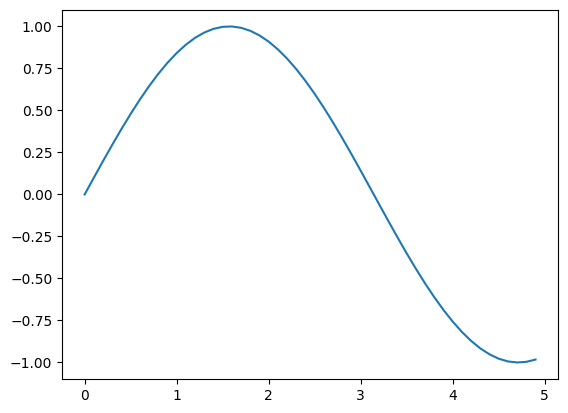

In [9]:
import numpy as np
import matplotlib.pyplot as plt
# 准备数据
x = np.arange(0, 5, 0.1)
y = np.sin(x)
# 绘制
re = plt.plot(x, y) # 返回的是Line2D对象。
print(re)
# 显示（根据环境输出，支持jupyter notebook 与 GUI）
plt.show()

- 上面代码中没有创建Figure与Axes对象，但实际这些细节都被pyplot封装起来，给使用者提供默认的、高效的使用方式。
- 但是如果想使用Figure，Axes等对象，其实可以在pyplot相关函数的返回值中得到，可以进行更多的属性设置，实现定制化的可视化效果。
- 对于没有特殊要求的、复杂的绘图，推荐使用pyplot的API函数来完成，因为pyplot封装实现了常见的图形的绘制。

- 我们用一张图来说明pyplot管理的对象，及其相关接口说明（接口函数太多，我们按照分类说明）。

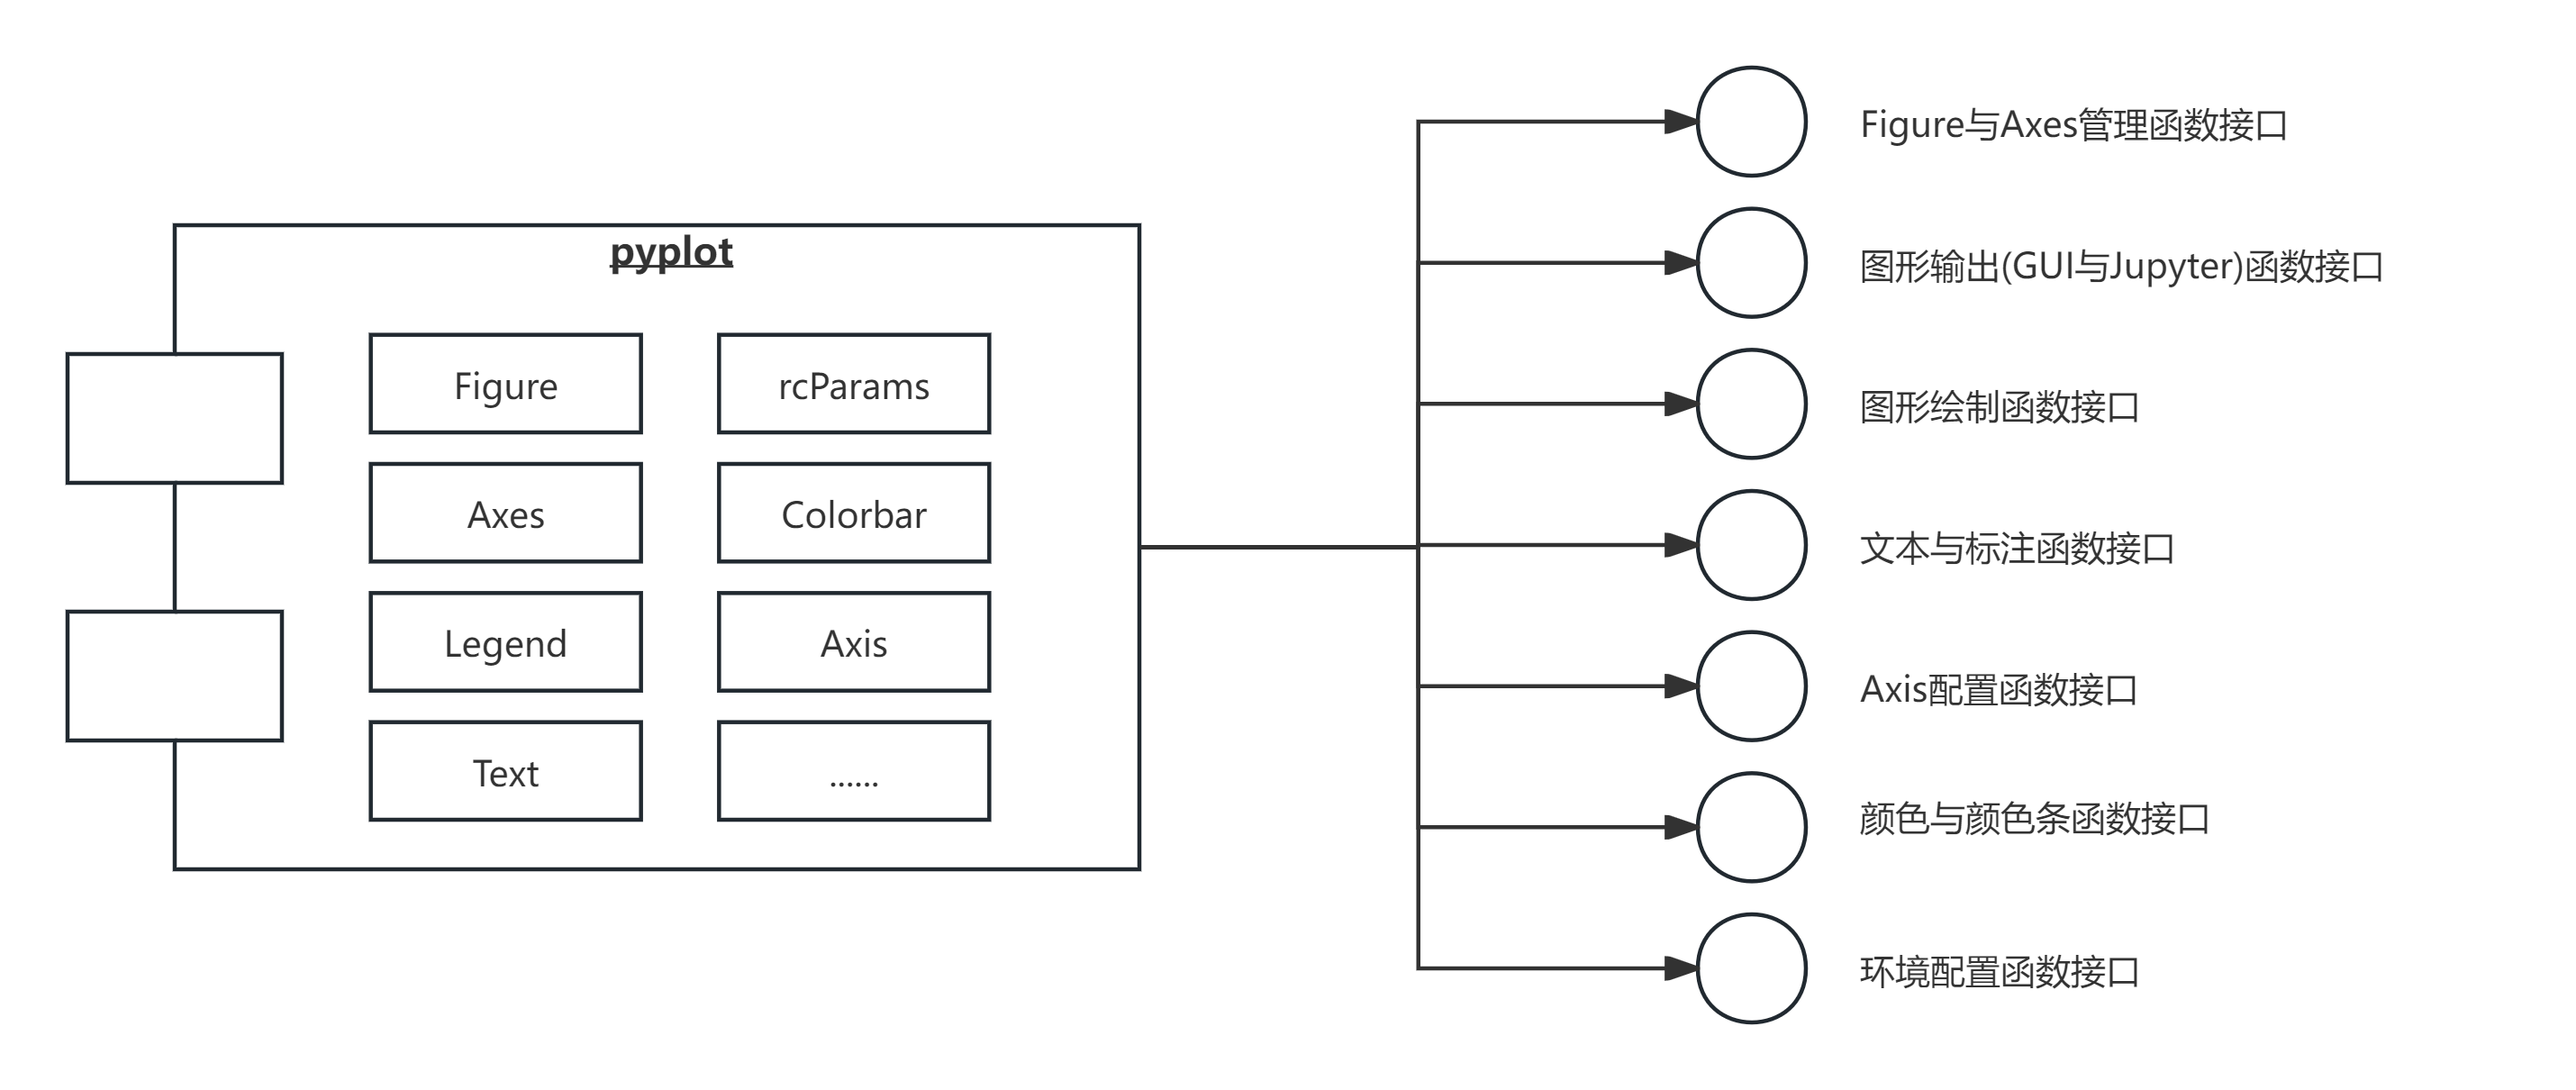

- 上面文本与标注本身也是图形绘制，下面我们放在图形绘制一起介绍。

# 1. Figure与Axes管理

- pyplot不仅创建Figure与Axes，而且还管理创建的Figure与Axes对象，对于同时使用多个Figure的情况，这种管理是非常有用的。

## 1.1. 使用pyplot创建对象

- 在pyplot主要管理两个核心对象Figure与Axes，我们就重点介绍使用pyplot创建Figure与Axes对象。

### (1) 创建Figure对象

- pyplot提供figure函数来创建Figure对象，并且对创建的figure对象进行管理。figure函数的参数与Figure构造器的参数大部分相似。

- Figure构造器的原型定义：

```python
class matplotlib.figure.Figure(
    figsize=None, 
    dpi=None, 
    *, 
    facecolor=None, 
    edgecolor=None, 
    linewidth=0.0, 
    frameon=None, 
    subplotpars=None, 
    tight_layout=None, 
    constrained_layout=None, 
    layout=None, 
    **kwargs)
```

- figure函数的原型定义：

```python
matplotlib.pyplot.figure(
    num=None, 
    figsize=None, 
    dpi=None, 
    *,   # 用来分隔位置参数与关键字参数，星号后面的参数必须强制使用关键字。
    facecolor=None, 
    edgecolor=None, 
    frameon=True, 
    FigureClass=<class 'matplotlib.figure.Figure'>, 
    clear=False, **kwargs)
```

- figure函数的所有参数都是可选的，其中主要参数的作用如下：
    - num: 可以是int，str，Figure对象，SubFigure对象。
        - 参数是int类型，参数就是Figure对象的编号，如果编号存在，则直接激活该figure对象为当前Figure，不存在则直接创建一个。创建的Figure对象的编号就是该参数，并且可以使用Figure对象的number属性访问。
        - 参数是str类型，参数就是Figure对象的标签，其中编号自动生成，Figure对象的编号从1开始。
        - 参数是Figure类型，参数就是需要直接激活的Figure对象。
    - figsize：是个元组(float, float)，如果不设置，默认是(6.4, 4.8)，单位由dpi指定。比如dpi=100，则Figure对象就是`640*480`大小。
        - figsize的默认值，在环境参数`rcParams["figure.figsize"]`中可以设置。
    - dpi：dpi是因为缩写（dots-per-inch：每英寸的点数），是figsize的单位，`figsize * dpi`就是figure对象的尺寸。
        - dpi默认值是100，可以在环境参数`rcParams["figure.dpi"]`中设置。
    - facecolor：Figure画布的颜色。
        - facecolor的默认值是`white`，可以在环境参数`rcParams["figure.facecolor"]`中设置。
    - edgecolor：Figure边的颜色。
        - edgecolor的默认值是`white`，可以在环境参数`rcParams["figure.edgecolor"]`中设置。
    - frameon：是否绘制边框，类型是逻辑值。True就是绘制，False就是不绘制。
    - FigureClasssubclass：用来指定创建Figure对象的类，这里主要是使用者继承Figure类后子类化，实现一些定制功能。
    - clear：类型是逻辑值，用来确定如果Figure对象存在，是否清楚绘制内容，缺省值是False，表示不清楚。
    - layout：布局方式，类型是字符串或者LayoutEngine对象，默认是None，表示没有布局，取值：`{'constrained', 'compressed', 'tight', 'none', LayoutEngine, None},`
    - `**kwargs`表示可以使用Figure构造器的其他参数。

- Figure对象创建例子-1：全部采用默认值创建

1


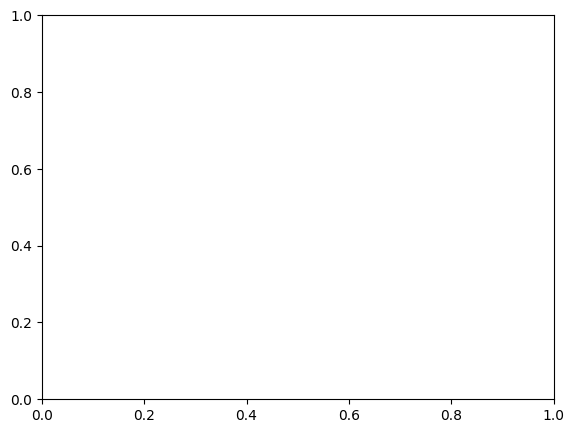

In [8]:
import matplotlib.pyplot as plt
from IPython.display import display

# 最简单的创建方式
fig = plt.figure()  # 返回Figure对象
print(fig.number)   # 默认创建的Figure对象编号是1
fig.add_axes([0.1, 0.1, 0.8, 0.8])
plt.show() 

- Figure对象创建例子-2：figsize与dpi参数使用，并且num参数使用字符串

1
Create Figure



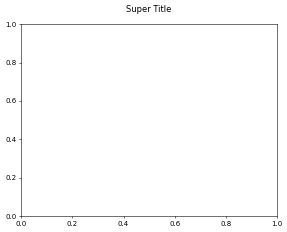

In [29]:
import matplotlib.pyplot as plt
from IPython.display import display

# num使用字符串，指定Figure对象的label属性。
fig = plt.figure(num="Create Figure", figsize=(6.4, 4.8), dpi=50)  # 返回Figure对象
print(fig.number)   # 默认创建的Figure对象编号是1
print(fig.get_label())   # num指定的字符串不是Figure对象的Title属性，而是label属性
print(fig.get_suptitle())
fig.suptitle("Super Title")

fig.add_axes([0.1, 0.1, 0.8, 0.8])
plt.show() 

- 注意：
    - num产生的label标签，不是Figure对象的上标题，label标签一般是所有Artist对象都具有的，一般是在Legend中使用。
    - Figure对象的label属性在画布上不显示。
    - 上面代码dpi=50，等于Figure对象尺寸是原来的一半。

- Figure对象创建例子-3：facecolor与edgecolor参数使用

1


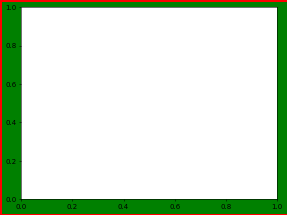

In [28]:
import matplotlib.pyplot as plt
from IPython.display import display

# 最简单的创建方式
fig = plt.figure(figsize=(6.4, 4.8), dpi=50, facecolor="green", edgecolor="red", frameon=True, linewidth=2)  # 返回Figure对象
print(fig.number)   # 默认创建的Figure对象编号是1

fig.add_axes([0.1, 0.1, 0.8, 0.8])
plt.show() 

- 代码说明：
    - 上面代码中如果设置`frameon=False`就没有Edge边界，由于坐标系的覆盖，会看不见`facecolor`的颜色。
    - 要看见`edgecolor`的颜色，需要使用Figure对象的`linewidth`属性.
    - 大部分情况下，Figure对象的label属性没有意义，所以很少设置num参数，让figure函数自动对figure.number进行编号。但是如果不在jupyter运行，pyplot会使用自己的独立GUI平台显示图像，label属性就是窗体的标题。请运行附件的`figure_label.py`程序测试效果。

- 下面是`figure-labe.py`源代码

```python
import matplotlib.pyplot as plt
from IPython.display import display

# 最简单的创建方式
fig = plt.figure(num="Create Figure", figsize=(6.4, 4.8), dpi=50)  # 返回Figure对象
fig.add_axes([0.1, 0.1, 0.8, 0.8])
plt.show() 
```

- 运行的界面如下：

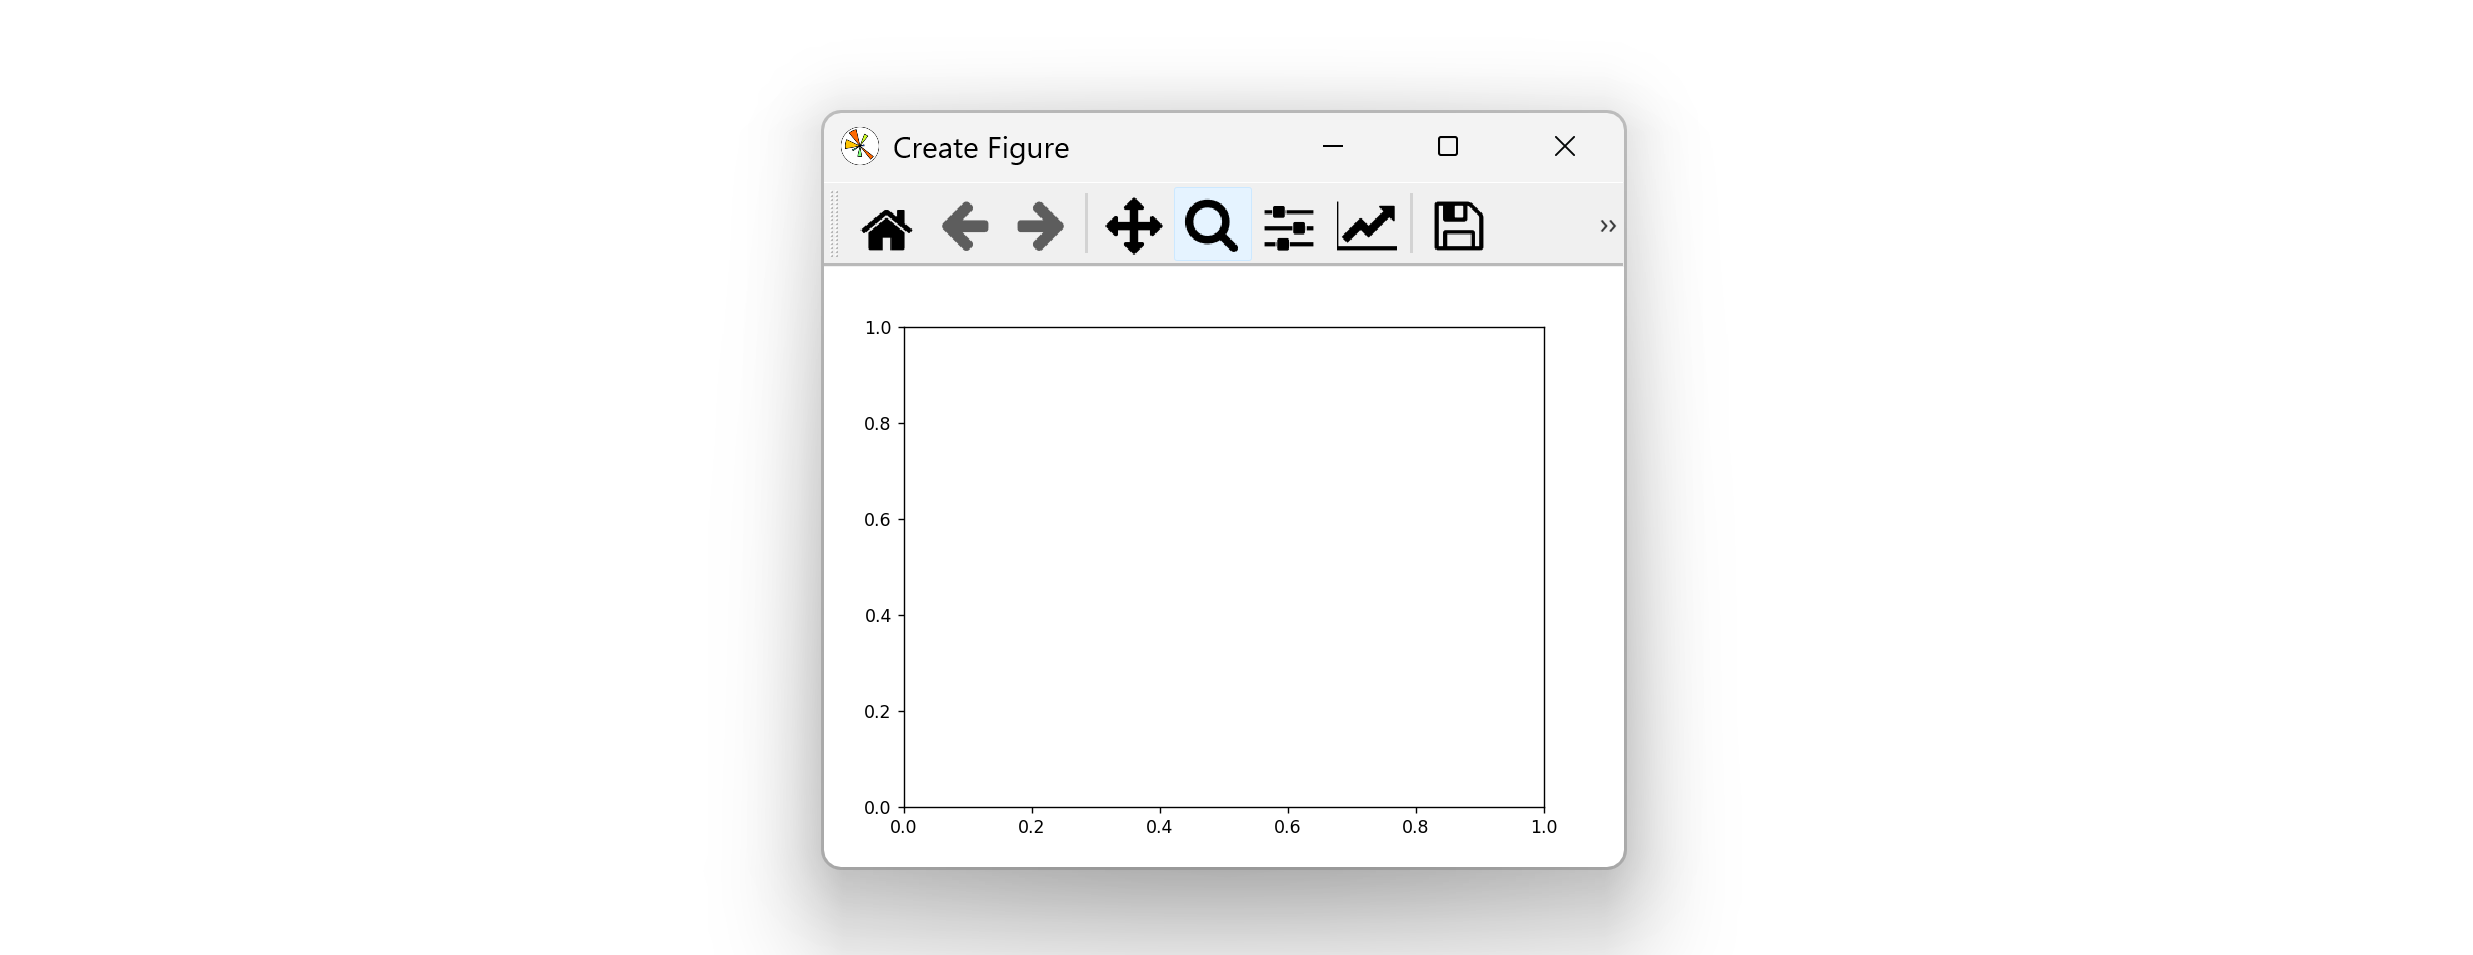

- 下面我们还能看到在jupyter中直接运行GUI模式。

- Figure对象创建例子-4：num使用一个已经创建的Figure对象

1
2
[1]
2290894806976 2290894806976


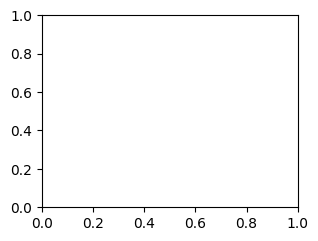

In [37]:
import matplotlib.pyplot as plt
from matplotlib.figure import Figure

# 首先使用Figure构造器创建一个对象
# fig1 = Figure(figsize=(3.2, 2.4))
fig1 = plt.figure(figsize=(3.2, 2.4))
print(fig1.number) 

fig1.number = 2
fig2 = plt.figure(num=fig1)  # 返回Figure对象
print(fig2.number)   # 默认创建的Figure对象编号是1

print(plt.get_fignums()) # 返回已经创建的Figure对象编号。
print(id(fig1), id(fig2)) # 比较两个对象地址, 判定对象是否是同一个对象
fig1.add_axes([0.1, 0.1, 0.8, 0.8])
plt.show() 

- 代码说明：
    - 在figure函数的num属性只能使用pyplot创建的对象，不能使用Figure构造器创建的对象。
    - 如果num指定的Figure对象可以使用，pyplot也仅仅是激活该Figure对象为当前对象，不会重新创建。使用`clear`属性还可以清楚原来Figure对象中的图形内容。
    - 这个例子说明，我们在使用pyplot模块的时候，需要注意：**尽量不要混合使用面向对象接口和pyplot接口创建对象**，尽量都在pyplot的管理环境中创建对象。

- Figure对象的属性，我们在后面专门用主题来介绍，这里仅仅介绍pyplot的figure函数创建Figure对象。

### (2) 创建Axes对象

- 在pyplot模块中提供了如下几个函数来创建Axes对象。
    - axes
    - subplot
    - subplots
    - subplot2grid
    - subplot_mosaic
- pyplot的某些图形绘制函数也会隐式创建Axes对象，甚至包括Figure对象，这些都是pyplot自动判断、创建与管理的。 

- 使用这些函数创建Axes的条件不同，创建的对象过程、数量都不同，有的函数可以同时创建多个Axes对象，但是最终都会返回创建好的Axes对象。

- axes函数原型定义`matplotlib.pyplot.axes(arg=None, **kwargs)`, 其参数可选，但是常见参数说明如下：
    - arg：4长的元组，用来指定坐标系在Figure对象画布上的位置与尺寸，格式是`(left, bottom, width, height)`, `left`与`bottom`说明以左下角作为坐标系原点。
        - 如果arg=None，则调用subplot创建一个新的、填满Figure对象画布的Axes对象。
        - arg参数还可以是一个已经创建的Axes对象。

- 函数`axes`的`**kwargs`还有其他关键字参数，这些参数是必须使用关键字参数名的。
    - projection：坐标系类型。取值含义如下：
        - None / 'rectilinear'：二维直角坐标系，回忆初中数学的知识。
        - 'polar'：极坐标系，回忆初中数学的知识。
        - '3d'：三维坐标系，回忆初中数学的知识。
        - 'aitoff'：由俄国地理学家 David A. Aitoff 1889 年提出的坐标系。它在天文学和地理学中常用于展示全天球或全球数据。
        - 'hammer'：Hammer坐标系（也称为Hammer-Aitoff坐标系）是Aitoff投影的一种等积改良版本，由德国数学家Ernst Hammer于1892年提出。它在保持等积特性的同时，减少了边缘区域的形状畸变。
        - 'lambert'：Lambert坐标系是一类由约翰·海因里希·兰伯特在1772年提出的地图坐标系，主要包括两种主要类型：**Lambert等角圆锥投影**与**Lambert等积方位投影**
        - 'mollweide'：由德国数学家兼天文学家卡尔·勃兰登堡·莫尔韦德于1805年提出。这是一种等积投影，意味着它保持面积比例的正确性。
    - polar：类型是逻辑值，如果取值True等价于projection='polar'。
    - sharex, sharey：类型是Axes，表示使用另外一个坐标系的坐标轴，包括一样的刻度，大小等属性。
    - label：类型字符串，指定坐标系的标签。

- `axes`函数返回的是Axes对象

- Axes对象创建例子-1：使用axes函数创建Axes对象

0.125 0.10999999999999999 0.775 0.77


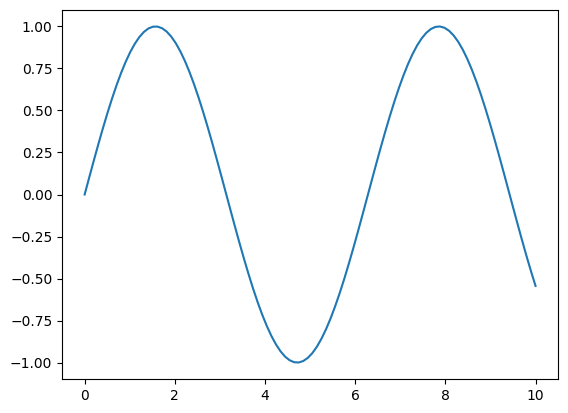

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# 创建坐标系
ax = plt.axes()  # 默认位置与大小 [0.125, 0.11, 0.775, 0.77]
# ax = plt.axes([0.1, 0.1, 0.8, 0.8])   # 指定坐标系的位置与大小。

rect = ax.get_position()  # 返回坐标系的位置与大小。
print(rect.x0, rect.y0, rect.width, rect.height)
ax.plot(x, y)

plt.show()

- 上面代码中，我们甚至不需要创建Figue对象，就可以直接创建坐标系，Figure对象在axes函数中实际是创建的，函数会根据情况自动创建。甚至可以直接使用plot绘图函数，plot也可会自动创建Figure对象与Axes对象。
- 如果不指定Axes对象的位置与大小，默认是`(0.125, 0.11, 0.775, 0.77)`

- Axes对象创建例子-2：使用axes函数创建极坐标系

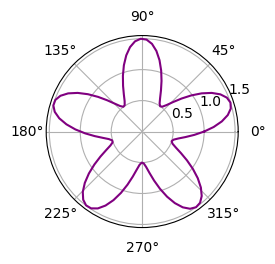

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# 方法3: 创建极坐标 Axes
fig = plt.figure(figsize=(3.2, 2.4))

# 创建极坐标 Axes
ax_polar = plt.axes([0.1, 0.1, 0.8, 0.8], projection='polar')

theta = np.linspace(0, 2*np.pi, 100)  # 角（单位是弧度）
# r = np.sin(theta)  # 正弦曲线
r = 1 + 0.5 * np.sin(5*theta)  # 更好看的正弦曲线 

ax_polar.plot(theta, r, 'purple')

plt.show()

- Axes对象创建例子-3：使用axes函数创建'mollweide', 'hammer', 'aitoff', 'lambert'坐标系

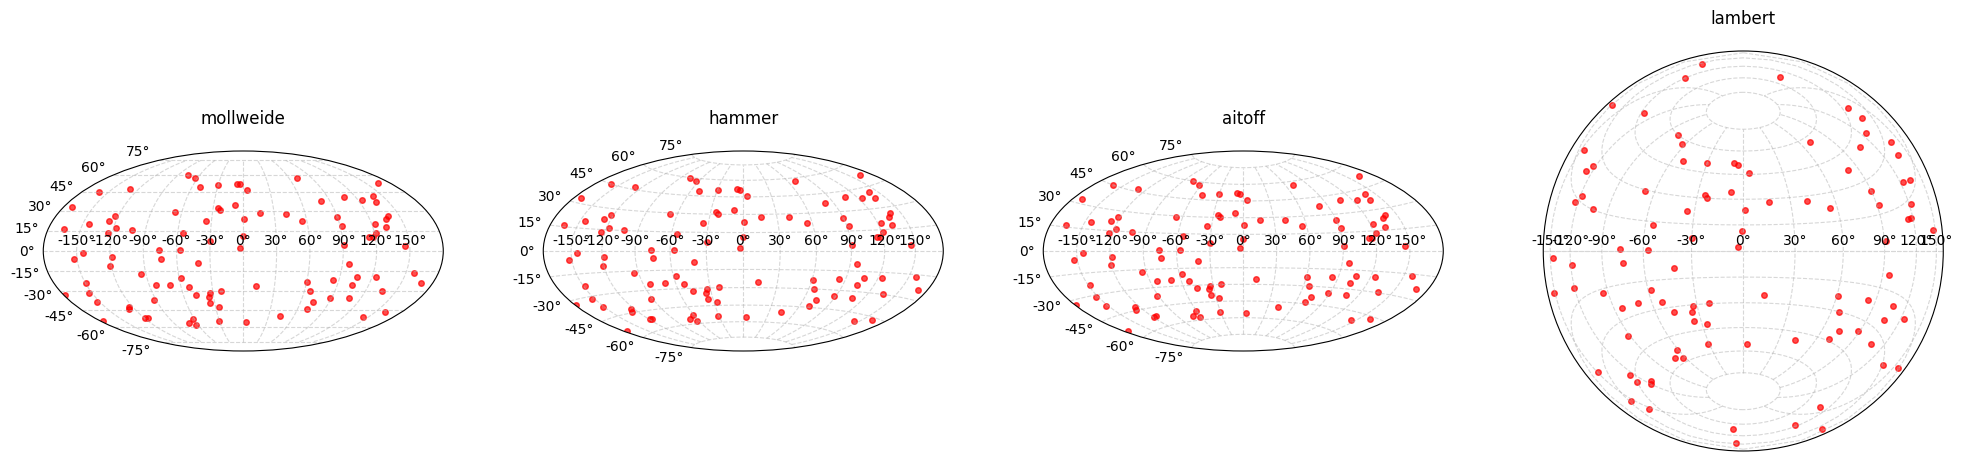

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# 测试数据（经纬度）
lon_deg = np.random.uniform(-180, 180, 100)  # 均匀分布
lat_deg = np.random.uniform(-60, 60, 100)
lon_rad = np.radians(lon_deg)  # 角度转弧度
lat_rad = np.radians(lat_deg)

# 创建图表对象
fig = plt.figure(figsize=(20, 6))

# 创建坐标系
ax_mollweide = plt.axes([0.0,  0.1, 0.2, 0.8], projection='mollweide')
ax_hammer    = plt.axes([0.25, 0.1, 0.2, 0.8], projection='hammer')
ax_aitoff    = plt.axes([0.5,  0.1, 0.2, 0.8], projection='aitoff')
ax_lambert   = plt.axes([0.75,  0.1, 0.2, 0.8], projection='lambert')

ax_mollweide.scatter(lon_rad, lat_rad, color='red', s=16, alpha=0.7)
ax_mollweide.grid(True, linestyle='--', alpha=0.5)
ax_mollweide.set_title("mollweide", pad=20, fontsize=12)

ax_hammer.scatter(lon_rad, lat_rad, color='red', s=16, alpha=0.7)
ax_hammer.grid(True, linestyle='--', alpha=0.5)
ax_hammer.set_title("hammer", pad=20, fontsize=12)

ax_aitoff.scatter(lon_rad, lat_rad, color='red', s=16, alpha=0.7)
ax_aitoff.grid(True, linestyle='--', alpha=0.5)
ax_aitoff.set_title("aitoff", pad=20, fontsize=12)

ax_lambert.scatter(lon_rad, lat_rad, color='red', s=16, alpha=0.7)
ax_lambert.grid(True, linestyle='--', alpha=0.5)
ax_lambert.set_title("lambert", pad=20, fontsize=12)

plt.show()

- 代码说明：
    - 上面代码用到了坐标系的标题与网格线属性，我们后面对争对Axe的属性做专门主题介绍，这里体验不同坐标系的效果，具体属性不做介绍。
    - 这里提醒一下，Label属性与Title属性作用在Matplotlib中是不一样的。label的主要作用是用于legend图例中的名字识别。

- Axes对象创建例子-4：axes函数使用已经创建的axes对象
    - pyplot的axes函数还有一个功能就是，绑定已经创建的Axes对象到Figure对象。下面使用例子来说明。

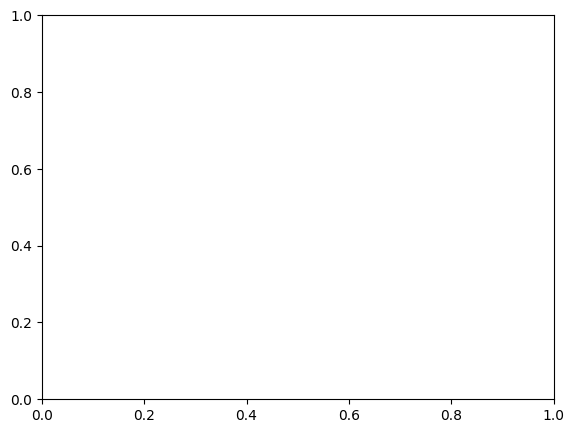

In [4]:
import matplotlib.pyplot as plt
from matplotlib.axes import Axes

axes = Axes(plt.gcf(), [0.1, 0.1, 0.8, 0.8])  # 也可以使用figure撞见一个Figure对象。
# 绑定axes与figure的关系
plt.axes(axes)  # 绑定Axes对象到当前Figure对象
plt.show()

- 代码说明：
    - 我们使用`gcf()`函数获取当前Figure对象，在下面Figure与Axes对象管理专门说明。
    - 我们可以体验到axes函数的作用等价于Figure对象的`add_axes`函数的功能。
    - 对于Figure对象，Axes对象依赖的环境要简单点，主要依赖Figure对象。而Figure对象依赖的环境复杂的多，尤其在pyplot模块中提供了显示平台，Figure依赖这些Matplotlib以外的环境，自然依赖关系会复杂点，我们在使用Figure构造器构造与使用pyplot的figure函数构造的Figure对象，一定要注意这种差异，在混用的时候一定要特别小心，我们推荐尽量不要混用，同时推荐如果想依赖jupyter与GUI这样现实平台的情况下，最好使用pyplot的figure函数创建Figure对象。

- Axes对象创建例子-5：使用subplot创建对象

- 上面介绍的axes函数也是调用subplot创建Axes对象的，创建的对象通过axes函数的返回值返回，subplot函数的原型定义如下：
    - `matplotlib.pyplot.subplot(*args, **kwargs)` 

- `subplot`函数的参数与`axes`基本一样，除了args参数，kwargs参数主要来自Axes对象的属性。下面是对args参数的说明：
    - args：该参数有三种形式：
        - 三个整数，格式`(nrows, ncols, index)`，表示创建nrows行，ncols列的多个坐标系，index表示创建多个坐标系中的第index个坐标系。
        - 一个三个数字的整数，三个数字分别对应上面说明的`(nrows, ncols, index)，这是一种简化方式，前提是行数与列数不能超过9。
        - SubplotSpec对象，用来专门设置坐标系的相关属性，主要使用 GridSpec规范来设置行列，而不是nrows与nclos，来指定坐标系的网格中的位置。
    - 其他与`axes`函数一样的主要属性参数：projection, polar, sharex, sharey, label已经在axes函数中介绍过了。

- subplot函数尽管设置多行多列，但是每次只创建一个Axes对象，nrows与ncols用来规划未来创建的坐标系的布局，当然也可以规划设计一行一列。下面是的使用代码。

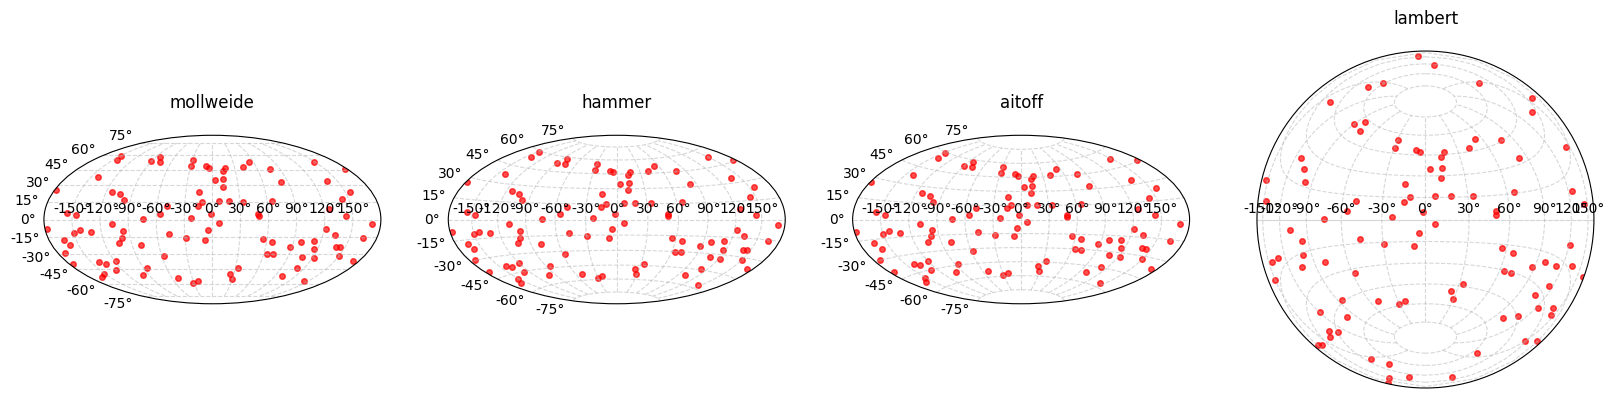

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 测试数据（经纬度）
lon_deg = np.random.uniform(-180, 180, 100)  # 均匀分布
lat_deg = np.random.uniform(-60, 60, 100)
lon_rad = np.radians(lon_deg)  # 角度转弧度
lat_rad = np.radians(lat_deg)

# 创建图表对象
fig = plt.figure(figsize=(20, 6))

# 创建坐标系
ax_mollweide = plt.subplot(1, 4, 1, projection='mollweide')
ax_hammer    = plt.subplot(1, 4, 2, projection='hammer')
ax_aitoff    = plt.subplot(1, 4, 3, projection='aitoff')
ax_lambert   = plt.subplot(1, 4, 4, projection='lambert')

ax_mollweide.scatter(lon_rad, lat_rad, color='red', s=16, alpha=0.7)
ax_mollweide.grid(True, linestyle='--', alpha=0.5)
ax_mollweide.set_title("mollweide", pad=20, fontsize=12)

ax_hammer.scatter(lon_rad, lat_rad, color='red', s=16, alpha=0.7)
ax_hammer.grid(True, linestyle='--', alpha=0.5)
ax_hammer.set_title("hammer", pad=20, fontsize=12)

ax_aitoff.scatter(lon_rad, lat_rad, color='red', s=16, alpha=0.7)
ax_aitoff.grid(True, linestyle='--', alpha=0.5)
ax_aitoff.set_title("aitoff", pad=20, fontsize=12)

ax_lambert.scatter(lon_rad, lat_rad, color='red', s=16, alpha=0.7)
ax_lambert.grid(True, linestyle='--', alpha=0.5)
ax_lambert.set_title("lambert", pad=20, fontsize=12)

plt.show()

- 代码说明：
    - 我们只是把上一个列子中代码的axes函数改成subplot而已。
    - 通过代码比较，明显axes需要我们自己指定位置与尺寸来布局多个坐标系。这一切在subplot函数中，全部自动计算位置与尺寸。
    - 对于在多个坐标系的情况下，使用subplot代码会更加简洁，下面我们可以优化上面代码。

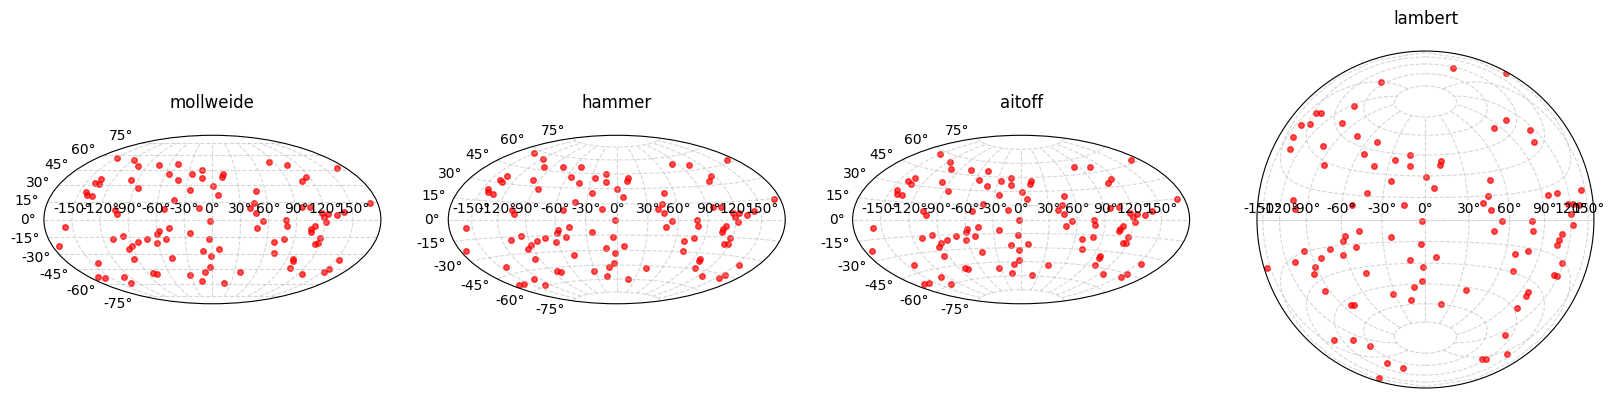

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# 测试数据（经纬度）
lon_deg = np.random.uniform(-180, 180, 100)  # 均匀分布
lat_deg = np.random.uniform(-60, 60, 100)
lon_rad = np.radians(lon_deg)  # 角度转弧度
lat_rad = np.radians(lat_deg)

# 创建图表对象
fig = plt.figure(figsize=(20, 6))
projections = ['mollweide', 'hammer', 'aitoff', 'lambert']

# 使用循环创建坐标系
for idx, projection in  enumerate(projections): # 从0开始
    ax = plt.subplot(1, 4, idx+1, projection=projection)   # index从1开始的。
    ax.scatter(lon_rad, lat_rad, color='red', s=16, alpha=0.7)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_title(projection, pad=20, fontsize=12)

plt.show()

- subplot函数最大特点是可以在规划好的行列网格中创建Axes对象，在pyplot中提供了SubplotSpec对象来指定在规划网格中的位置，网格规划可以使用GridSpec对象来完成。
    - GridSpec对象可以使用构造器构建，也可以使用Figure提供的`add_gridspec`函数创建网格规范。关于网格布局，在详细介绍Figure属性的时候，我们专门介绍，这里仅仅是说明subplot函数中SubplotSpec对象使用，以及多个坐标系的网格布局效果。
    - 一般我们不会直接使用SubplotSpec构造器来构建SubplotSpec对象，一般都是通过GridSpec对象获取一个SubplotSpec对象。

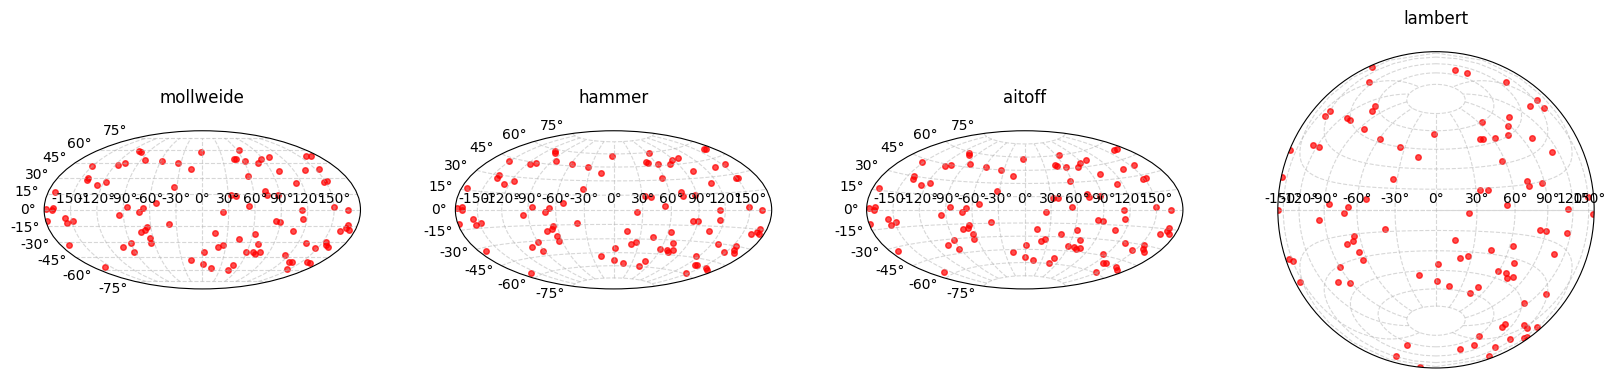

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 测试数据（经纬度）
lon_deg = np.random.uniform(-180, 180, 100)  # 均匀分布
lat_deg = np.random.uniform(-60, 60, 100)
lon_rad = np.radians(lon_deg)  # 角度转弧度
lat_rad = np.radians(lat_deg)

# 创建图表对象
fig = plt.figure(figsize=(20, 6))
# 创建一个1行4列的网络布局
# gs = fig.add_gridspec(1, 4)
gs = plt.GridSpec(1, 4, figure=fig, hspace=0.3, wspace=0.3)

projections = ['mollweide', 'hammer', 'aitoff', 'lambert']

# 使用循环创建坐标系
for idx, projection in  enumerate(projections): # 从0开始
    ax = plt.subplot(gs[0, idx], projection=projection)   # 使用网格布局对象gs，并通过下标得到SubplotSpec对象。
    ax.scatter(lon_rad, lat_rad, color='red', s=16, alpha=0.7)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_title(projection, pad=20, fontsize=12)

plt.show()

- 代码说明：
    - 我们使用`gs = fig.add_gridspec(1, 4)`创建一个网格布局规范。
    - 然后我们使用`gs[0, idx]`得到一个SubplotSpec对象，并在subplot函数中使用。
    - `gs = plt.GridSpec(1, 4, figure=fig, hspace=0.3, wspace=0.3)`是使用构造器构建，其中还有更多属性设置。

- 在后面介绍Figure的add_subplot函数的时候，大家可以感觉得到：pyplot的subplot函数实际是对Figure对象的add_subplot函数的二次封装。

- Axes对象创建例子-6：使用subplots创建对象

- subplots函数创建多个坐标系，同时创建Figure对象，创建的Axes对象与Figure对象通过函数返回值返回。
    - 如果创建一个Axes对象就返回Axes对象，如果创建多个Axes对象，则返回Axes对象数组。
    - subplots函数返回两个值，第一个是Figure对象，第二个是Axes对象或者Axes对象数组。

- `subplots`函数的原型定义与参数说明如下：

```python
matplotlib.pyplot.subplots(
    nrows=1, ncols=1,   # 通过行数与列数，设置创建Axes对象的数量
    *,   # 位置参数与关键字参数的分隔位置，前面是位置参数，后面是关键字参数
    sharex=False, sharey=False,  # 是否采用相同的x与y轴。
    squeeze=True,   # 是否挤压返回的Axes对象数组。True表示挤压，挤压的结果是，如果nrows=1, ncols=1，创建一个Axes对象，则直接返回Axes对象，而不是[1,1]数组，如果是nrows=1, ncols=n或者nrows=n, ncols=1，则返回1维数组，而不是二维数组。默认值是True。
    width_ratios=None, # 该参数来自GridSpec，指定每个坐标系的相对宽度。类型是一个float数组，该参数在gridspec_kw也可以设置,长度为ncols，该参数不设置，这每个坐标系一样宽度。
    height_ratios=None, # 指定每个坐标系的相对高度，长度为ncols
    subplot_kw=None,  # 与Figure对象的add_subplot函数的参数，（也是pyplot的axes函数与subplot函数）
    gridspec_kw=None, # GridSpec对象的属性参数
    **fig_kw)  # 用来指定Figure对象的属性。该参数前的**表示与上面两个参数的使用方法不同。
```

- subplots函数的特点是只能创建类型一样的坐标系，因为是批量创建Axes对象。

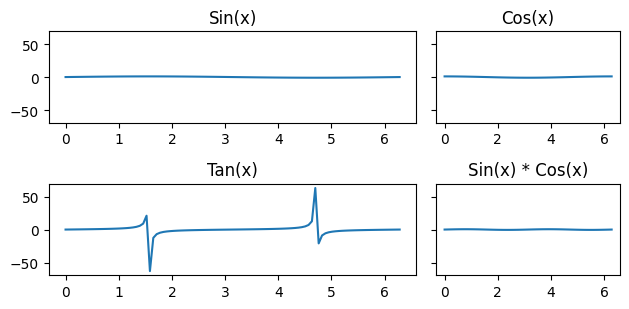

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# 创建示例数据
x = np.linspace(0, 2*np.pi, 100)
y1 = np.sin(x)  # 正弦曲线
y2 = np.cos(x)  # 余弦曲线
y3 = np.tan(x)  # 正切曲线
y4 = np.sin(x) * np.cos(x)  # 依然是正弦曲线

# 创建 2x2 的子图网格
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(6.4, 3.2), squeeze=False, width_ratios=[4, 2], sharey=True)

# 在第一个子图中绘图
axes[0, 0].plot(x, y1)
axes[0, 0].set_title('Sin(x)')

# 在第二个子图中绘图
axes[0, 1].plot(x, y2)
axes[0, 1].set_title('Cos(x)')

# 在第三个子图中绘图
axes[1, 0].plot(x, y3)
axes[1, 0].set_title('Tan(x)')

# 在第四个子图中绘图
axes[1, 1].plot(x, y4)
axes[1, 1].set_title('Sin(x) * Cos(x)')

# 调整子图之间的间距（自动避免坐标系之间的重叠）
plt.tight_layout()

# 显示图形
plt.show()

- 代码说明:
    - 使用subplots创建的坐标系，其中的图形绘制可以根据创建的Axes对象，进行定制绘制。
    - 使用`width_ratios=[4, 2]`, 可以控制每个坐标系的相对比例。
    - `plt.tight_layout()`可以简洁的避免坐标系之间的重叠，因为pyplot自动计算调整坐标系之间的间距。
    - 因为tan的值会很大，y轴坐标刻度会很大，使用`sharey=True`，可以保持所有y坐标都一样。这样的也会导致一些问题：当Y轴的值大小差距很大，上面的正弦曲线与余弦曲线会看起来像条直线。
    - figsize是`**fig_kw`参数的使用。

- Axes对象创建例子-7：使用subplot2grid创建对象

- subplot2grid函数比起上面函数的特点是可以更加方便创建复杂布局，包括subplot_mosaic函数也是提供另外一个创建具有布局的Axes对象的简洁选项。尤其是网格的单元格合并。
- subplot2grid函数原型定义与参数说明如下：

```python
matplotlib.pyplot.subplot2grid(
    shape, # 类型是(int, int)，用来设置坐标轴所在的网格的行数与列数
    loc,   # 类型是(int, int)，用来设置坐标轴所在行与列
    rowspan=1,  # 类型是int，用来设置坐标轴占据多行的行数
    colspan=1,  # 类型是int，用来设置坐标轴占据多列的列数
    fig=None,   # 用来设置坐标系所在的Figure对象，默认是当前Figure对象
    **kwargs)   # 用来设置其他与add_subplot函数中的参数
```

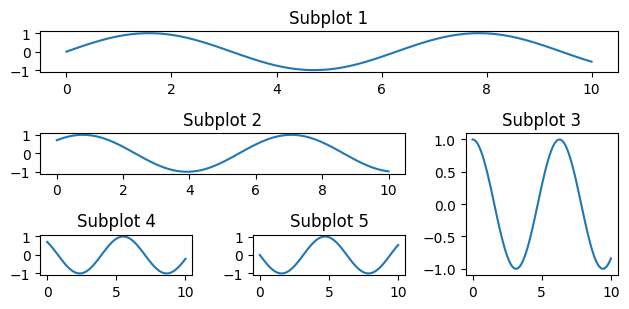

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# 创建示例数据
x = np.linspace(0, 10, 100)

# 示例3: 不均匀坐标系布局
fig = plt.figure(figsize=(6.4, 3.2))

# 创建不均匀的坐标系布局
ax1 = plt.subplot2grid((3, 3), (0, 0), colspan=3)  # 3行3列的布局，在0,0单元格，占据1行3列
ax2 = plt.subplot2grid((3, 3), (1, 0), colspan=2)  # 3行3列的布局，在1,0单元格，占据1行2列
ax3 = plt.subplot2grid((3, 3), (1, 2), rowspan=2)  # 3行3列的布局，在1,2单元格，占据2行1列
ax4 = plt.subplot2grid((3, 3), (2, 0))  # 3行3列的布局，在2,0单元格，占据1行1列
ax5 = plt.subplot2grid((3, 3), (2, 1))  # 3行3列的布局，在2,1单元格，占据1行1列

# 在各个坐标系中绘图
axes = [ax1, ax2, ax3, ax4, ax5]
for i, ax in enumerate(axes):
    ax.plot(x, np.sin(x + i * np.pi/4))
    ax.set_title(F'Subplot {i+1}')

plt.tight_layout()
plt.show()

- 代码说明：
    - 在这种自动布局的Figure中，可以调用`plt.tight_layout()`来调整布局元素之间的间距。
    - subplot2grid函数返回的Axes对象，利用返回的对象可以设置Axes对象的属性，得到更好的可视化体验。

- Axes对象创建例子-8：使用subplot_mosaic创建对象

- `subplot_mosaic`函数基于ASCII嵌套列表构建复杂坐标系布局。这是一个辅助函数，用于**直观地构建**复杂的GridSpec布局。其函数原型定义如下：

```python
matplotlib.pyplot.subplot_mosaic(
    mosaic, 
    *, 
    sharex=False, sharey=False,               # 是否共享x轴，y轴
    width_ratios=None, height_ratios=None,    # 行、列宽的相对比例，类型是数组，长度与行列数对齐
    empty_sentinel='.',  # 设置留空的字符，默认是点字符
    subplot_kw=None,     # Figure.add_subplot中的参数在这儿设置
    gridspec_kw=None,    # 设置 GridSpec的属性
    per_subplot_kw=None, # 类型是字典，用来设置每个坐标系的属性，每个字典属性设置的是Figure.add_subplot参数，如果冲突，该参数优先于subplot_kw。该字典的key来自mosaic参数中字符串
    **fig_kw)  # 设置Figure的属性
```

- subplot_mosaic函数中mosaic参数说明：
    - 类型是二维列表（行列），以便可视化显示坐标系布局，列表中是Axes对象的标签。其中相同标签，标识坐标系占据的行列。下面是一个例子说明

```python
[['A Axes', 'A Axes', 'B Axes'],
 ['C Axes', '.',      'B Axes']]
```

- 上面的例子中一共三个坐标系，他们的标签分别是：`A Axes`，`B Axes`，`C Axes`。
    - `A Axes`: 占据1行2列
    - `B Axes`: 占据2行1列
    - `C Axes`: 占据1行1列
    - `.`：空出1行1列

- mosaic参数还可以是字符串，这种情况一般用于Axes的label属性是一个字符的情况。下面是例子：
```python
"""
AAB
C.B
"""
```

- subplot_mosaic函数中per_subplot_kw参数说明：
    - per_subplot_kw是一个字典类型，其key就是mosaic字符串（上面第一种情况）或者字符（上面第二种情况）。
    - per_subplot_kw字典的值，也是一个字典，用来设置Axes的属性值，其key为属性，值为属性值。下面是一个例子。

```python
per_subplot_kw['A Axes'] = {
    'facecolor' : 'red',
    'projection': 'polar'
}
```

或者使用下面等价的形式：

```python
per_subplot_kw= {
    'A Axes': {
        'facecolor' : 'red',
        'projection': 'polar'
    }, 
}
```

- 下面使用一个例子说明：

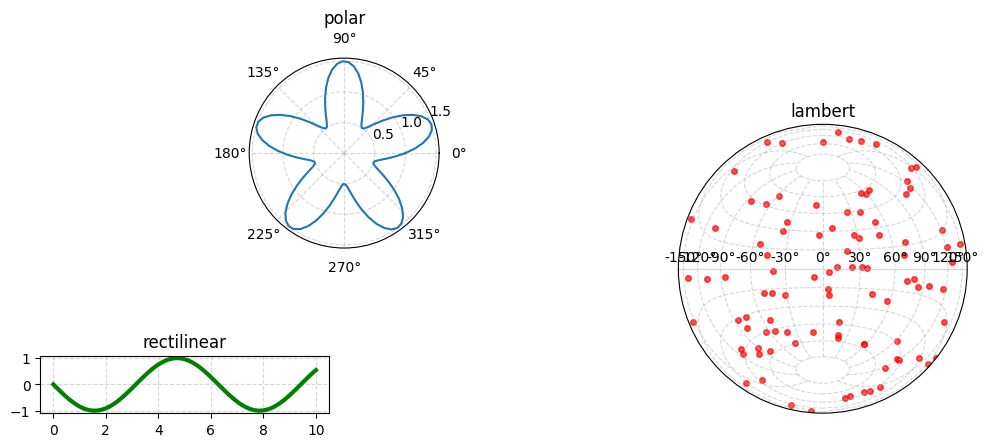

In [35]:
import matplotlib.pyplot as plt
import numpy as np
# 定义科学数据可视化布局
mosaic = """
    AAB
    C.B
"""
# 定义每个坐标系的属性
per_subplot_kw = {
    'A': {
        'projection': 'polar',
        'facecolor': 'white'
    },
    'B': {
        'projection': 'lambert',
        'facecolor': 'white'
    },
    'C': {
        'aspect': 'equal',
        'facecolor': 'white'
    },
}

# 为不同类型的数据设置合适的坐标系统
fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(10, 5),
    per_subplot_kw = per_subplot_kw
)

theta = np.linspace(0, 2*np.pi, 100)  # 角（单位是弧度）
r = 1 + 0.5 * np.sin(5*theta)  # 更好看的正弦曲线 

# 坐标系A - 极坐标
axes['A'].plot(theta, r)
axes['A'].set_title('polar')
axes['A'].grid(True, linestyle='--', alpha=0.5)


# 坐标系B - lambert地图坐标
lon_deg = np.random.uniform(-180, 180, 100)  # 均匀分布
lat_deg = np.random.uniform(-60, 60, 100)
lon_rad = np.radians(lon_deg)  # 角度转弧度
lat_rad = np.radians(lat_deg)
axes['B'].scatter(lon_rad, lat_rad, color='red', s=16, alpha=0.7)
axes['B'].set_title('lambert')
axes['B'].grid(True, linestyle='--', alpha=0.5)

# 坐标系C - 直角坐标系
x = np.linspace(0, 10, 100)
y = np.sin(x + i * np.pi/4)
axes['C'].plot(x, y, 'green', linewidth=3)
axes['C'].set_title('rectilinear')
axes['C'].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 1.2. 当前对象管理 

- 在上面我们的例子中，我们没有特别关注Axes对象与Figure对象的关系。在pyplot内部实际使用当前Figure与当前Axes概念来管理Figure对象与Axes对象。如果在没有明确操作Figure对象与Axes对象的情况下，默认通过pyplot函数的操作效果都作用于当年Figure与Axes对象上。如果想对某个Figure与Axes对象操作，要么直接使用对象函数操作属性，要么通过pyplot操作，但是pyplot操作前需要切换当前Figure与Axes对象。

- 在pyplot提供了如下函数来管理Figure与Axes对象：
    - 访问当前Figure与Axes对象
        - `matplotlib.pyplot.gcf()`：返回Figure对象
        - `matplotlib.pyplot.gca()`：返回Axes对象
    - 将坐标系设置到当前Figure对象
        - `matplotlib.pyplot.sca(ax)`
    - 从当前Figure对象中移除Axes对象
        - `matplotlib.pyplot.delaxes(ax=None)`:当ax=None，就是把当前Axes从当前Figure对象移除。 
    - 清除当前Figure与Axes对象的内容
        - `matplotlib.pyplot.clf()`
        - `matplotlib.pyplot.cla()`

- pyplot没有提供设置当前Figure对象的专门函数，而是使用figure函数激活指定Figure对象为当前Figure对象。

- Figure与Axes对象管理例子：
    - 该例子中，我们不使用明确的Axes对象与Figure对象，只使用pyplot提供的函数处理。如果使用Figure对象与Axes对象，这是用户自己管理这些对象，不在我们这里介绍的范围之内。
    - 这个例子中使用两个Figure对象，两个Axes对象，通过切换当前Figure与Axes完成数据可视化。
        - 坐标系使用直角坐标系与极坐标系，数据采用前面例子中一样的正弦曲线可视化。

创建的Figure： 2326902579520 2326902579376
当前Figure： 2326902579376
当前Axes： 2326921247616


<Figure size 640x320 with 0 Axes>

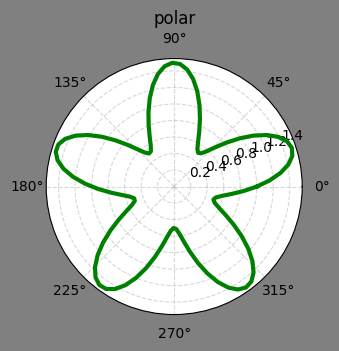

------切换Figure对象-------
当前Figure： 2326902579520
当前Axes： 2326912489680


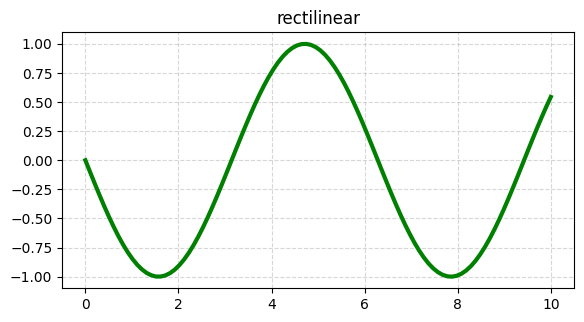

In [52]:
import matplotlib.pyplot as plt   # 只使用pyplot的函数
import numpy as np   # 处理坐标系中数据

# 创建两个Figure对象（默认最后一个创建的对象是当前Figure对象）
fig1 = plt.figure(num=1, figsize=(6.4, 3.2))
fig2 = plt.figure(num=2, figsize=(6.4, 3.2), facecolor="gray")  # 当前Figure对象
print("创建的Figure：", id(fig1), id(fig2))

#  -----通过切换当前Figure与Axes对象来完成数据可视化-----
ax_polar = plt.axes([0.1, 0.1, 0.8, 0.8], projection='polar')   # 当前Axes对象,而且与当前Figure对象关联。
print("当前Figure：", id(plt.gcf()))
print("当前Axes：", id(plt.gca()))
# 在当前Figure对象与Axes对象（极坐标系） 进行操作
theta = np.linspace(0, 2*np.pi, 100)  # 角（单位是弧度）
r = 1 + 0.5 * np.sin(5*theta)  # 更好看的正弦曲线 
plt.plot(theta, r, 'green', linewidth=3)
plt.gca().set_title('polar')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 切换到第一次创建的Figure对象与Axes对象
print("------切换Figure对象-------")
plt.figure(fig1)
ax_rectilinear = plt.axes([0.1, 0.1, 0.8, 0.8], projection='rectilinear') #当前Axes对象,而且与当前Figure对象关联。

print("当前Figure：", id(plt.gcf()))
print("当前Axes：", id(plt.gca()))

x = np.linspace(0, 10, 100)
y = np.sin(x + i * np.pi/4)

plt.plot(x, y, 'green', linewidth=3)
plt.gca().set_title('rectilinear')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

- 代码说明：
    - 特别需要注意，`ax_rectilinear = plt.axes([0.1, 0.1, 0.8, 0.8], projection='rectilinear') `创建的Axes对象是与当前Figure对象关联的，而且在切换当前Axes对象的时候，其父容器Figure对象也会切换。修改上面程序后可以更好体验，修改代码如下:

创建的Figure： 2326914986528 2326888525984
------切换Figure对象-------
创建的Axes： 2326905434128 2326911889904
------数据可视化-------
当前Figure： 2326914986528
当前Axes： 2326905434128
------切换Axes对象-------
当前Figure： 2326888525984
当前Axes： 2326911889904


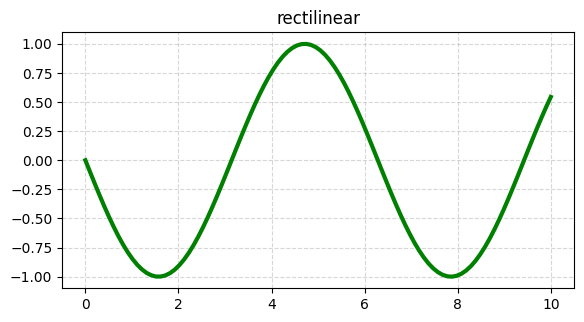

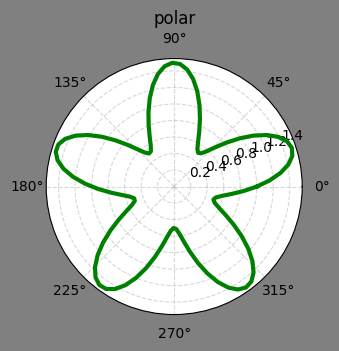

In [59]:
import matplotlib.pyplot as plt   # 只使用pyplot的函数
import numpy as np   # 处理坐标系中数据

# 创建两个Figure对象（默认最后一个创建的对象是当前Figure对象）
fig1 = plt.figure(num=1, figsize=(6.4, 3.2))
fig2 = plt.figure(num=2, figsize=(6.4, 3.2), facecolor="gray")  # 当前Figure对象
print("创建的Figure：", id(fig1), id(fig2))

# 直接在当前Figure创建Axes对象：fig2
ax_polar = plt.axes([0.1, 0.1, 0.8, 0.8], projection='polar')   # 当前Axes对象,而且与当前Figure对象关联。

# 切换Figure，并创建一个Axes：fig1
print("------切换Figure对象-------")
plt.figure(fig1)
ax_rectilinear = plt.axes([0.1, 0.1, 0.8, 0.8], projection='rectilinear') #当前Axes对象,而且与当前Figure对象关联。
print("创建的Axes：", id(ax_rectilinear), id(ax_polar))
# --- fig1->ax_rectilinear ,  fig2->ax_polar

#  -----在当前Axes可视化-----
print("------数据可视化-------")
print("当前Figure：", id(plt.gcf()))
print("当前Axes：", id(plt.gca()))
# 在当前Figure对象与Axes对象（极坐标系） 进行操作
x = np.linspace(0, 10, 100)
y = np.sin(x + i * np.pi/4)
plt.plot(x, y, 'green', linewidth=3)
plt.gca().set_title('rectilinear')
plt.grid(True, linestyle='--', alpha=0.5)

# -------------------------------------------------------------
# 切换到第一次创建的Figure对象与Axes对象
print("------切换Axes对象-------")
plt.sca(ax_polar)  # 切换Axes，其依赖的父容器Figure也会自动切换
print("当前Figure：", id(plt.gcf()))
print("当前Axes：", id(plt.gca()))
theta = np.linspace(0, 2*np.pi, 100)  # 角（单位是弧度）
r = 1 + 0.5 * np.sin(5*theta)  # 更好看的正弦曲线 
plt.plot(theta, r, 'green', linewidth=3)
plt.gca().set_title('polar')
plt.grid(True, linestyle='--', alpha=0.5)

# 显示所有Figure图表
plt.show()


# 2. 图形输出（GUI与Jupyter）

- Matplotlib的可视化数据，可以以图像方式输出，输出格式有两种：
    - 直接输出为图像文件，比如jpg，png，svg，bmp，tiff等
    - 输出到平台：比如jupyter notebook，GUI

- 对于GUI，还提供交互式输出。用户可以通过鼠标，键盘与图表互动，产生更好的可视化体验。我们把非交互式输出成为静态输出，包含图像文件与Jupyter notebook输出。在jupyter notebook输出一般不支持交互操作，因为其本质也是通过图像输出的，前面的讲解中也可以了解，比如我们使用了`IPython`模块中的`display`函数。

- 提示：
    - pyplot的show函数在非文件输出中，用来显示Figure对象，而且是显示所有Figure对象，而不仅仅是当前Figure对象。

## 2.1. 静态输出

### (1) 输出位图像文件

- 使用pyplot的savefig函数保存当前Figure对象为图像文件。`savefig`函数的原型定义为：
    - `matplotlib.pyplot.savefig(*args, **kwargs)`，该函数实际是Figure对象的savefig函数的二次封装，函数原型定义基本上完全一致。
    - 常见参数如下：

```python
savefig(
    fname,   # 保存的文件名，或者一个已经打开的文件对象，文件名的扩展名可以用来指定图像格式。如果设置了format参数，则format指定的格式优先，该格式也可以通过rcParams["savefig.format"]设置。 如果没有设置，则默认是png格式。
    *, 
    transparent=None, # 参数类型是逻辑值，指定Axes坐标系是否透明，Figure也一样，除非设置了facecolor与edgecolor参数,
    dpi='figure',  # 参数可以是float指定的单位，如果是figure，则使用figure对象的dpi。
    format=None,   # 指定文件输出的图像格式：'png', 'pdf', 'svg'等。
    metadata=None, # 用来指定输出图像文件的元数据，这个需要图像的专业知识，我们大部分时候不需要了解。
    bbox_inches=None, # figure的位置位置与大小。可以在rcParams["savefig.bbox"]中设置，类型是个Bbox对象，用来指定Figure在图像中的左上角顶点与右下角顶点。可以使用'tight'，由pyplot自动计算合理值
    pad_inches=0.1, # Figure周边的空白区域（补丁），可以在rcParams["savefig.pad_inches"]中设置，默认值是0.1，这个值在bbox_inches属性为'tight'时有效。也可以使用字符串'layout'，由pyplot自动计算合理值
    facecolor='auto', # 画布颜色，可以通过rcParams["savefig.facecolor"]设置。'auto'就是使用当前figure对象的facecolor。
    edgecolor='auto', # 边界颜色，可以通过rcParams["savefig.edgecolor"]设置。'auto'就是使用当前figure对象的edgecolor。
    backend=None,  # 指定图像保存的后端引擎,在matplotlib有一个模块就是专门介绍backend的。
    **kwargs  # 可以指定与PIL.Image.Image.save函数中的参数，比如：quality参数指定图像保存质量1-100（JPEG图像），这说明其中IO采用的是PIL模块中的实现。
)
```

- savefig函数，除了第一个参数，其他参数都是可选的。如果不考虑其他因素，则简单使用文件名就可以满足我们大部分需求。其中保存文件的后端一般默认，如果需要指定，可以从如下地址获取清单：`https://matplotlib.org/stable/users/explain/figure/backends.html#the-builtin-backends`
- 常见文件保存的后端由：
    - AGG：支持文件类型png
    - PDF：支持文件类型pdf
    - PS：支持文件类型ps, eps
    - SVG：支持文件类型svg
    - PGF：支持文件类型pgf, pdf
    - Cairo：支持文件类型png, ps, pdf, svg

- savefig的使用例子

图像已经保存


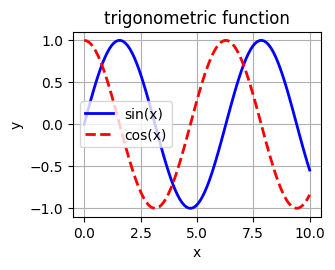

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 创建示例数据
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

# 创建图形
plt.figure(figsize=(3.2, 2.4), linewidth=3)
plt.plot(x, y1, 'b-', label='sin(x)', linewidth=2)
plt.plot(x, y2, 'r--', label='cos(x)', linewidth=2)
plt.title('trigonometric function')  # 三角函数
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

# 使用各种参数保存图形
plt.savefig(
    'sincos.png',  # 文件名
    dpi=300,                       # 分辨率（每英寸点数）
    bbox_inches='tight',           # 紧凑布局
    facecolor='lightgray',         # 图形背景色
    edgecolor='red',             # 图形边框颜色
    transparent=True,             # 是否透明
    pad_inches=0.1                 # 边距（英寸）
)

print("图像已经保存")

- 实际输出的图像效果如下：

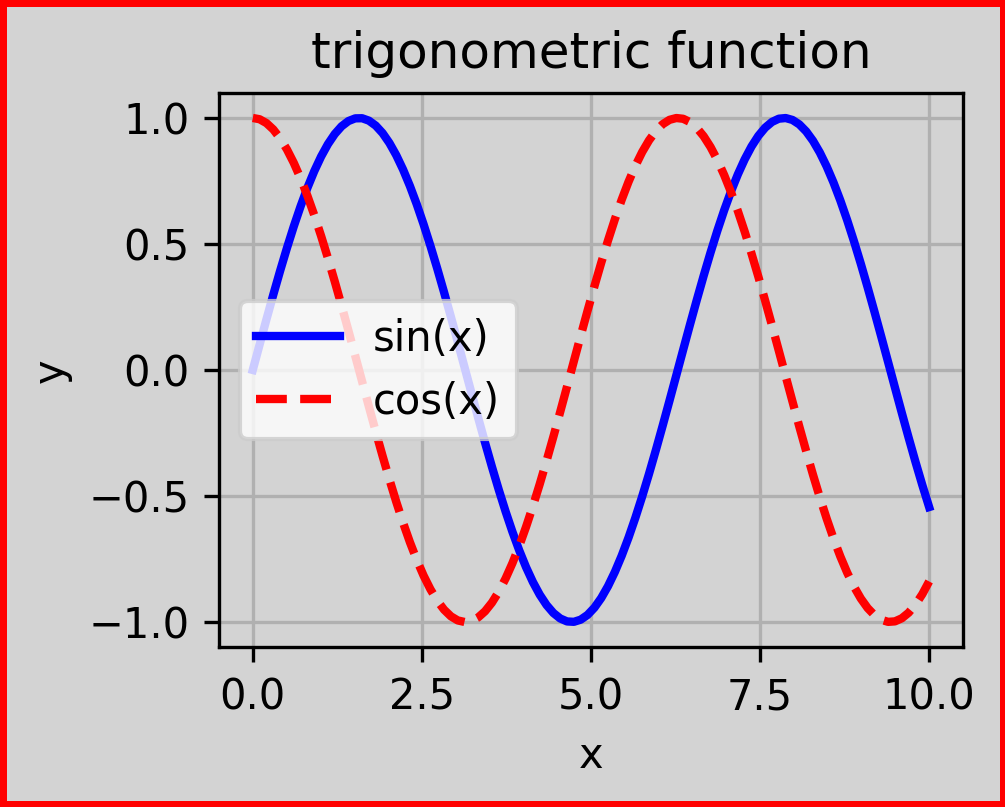

 -其中大部分情况下，只需要指定一个文件名就可以了，其他参数采用默认值就可以够用，除非您有特殊的需求。

### (2) 在jupyter notebook中输出

- 在jupyter notebook中已经默认提供输出支持，但实际上matplotlib早期还是提供了一系列魔法指令，用来处理matplotlib与notebook的协作。
    - %matplotlib inline：在Notebook中内嵌显示图形，图形会直接显示在代码单元格下方
    - %matplotlib notebook：使用交互式后端，图形可缩放、平移，支持动态更新
    - %matplotlib widget：使用ipympl后端，提供丰富的交互控件（需要安装ipympl）
    - %matplotlib tk / qt / wx / gtk：使用指定的GUI后端在新窗口中显示图形 （qt是常用的QT GUI，tk是python内置的Tinker GUI，gtk是Linux下的GIMP Toolkit GUI，wx是wxPython GUI）
    - %matplotlib auto：自动选择可用的GUI后端
    - %config：配置matplotlib参数

- %matplotlib inline已经默认，甚至连`plt.show()`都可以不调用。（`plt.show()`在GUI后端还是需要的）

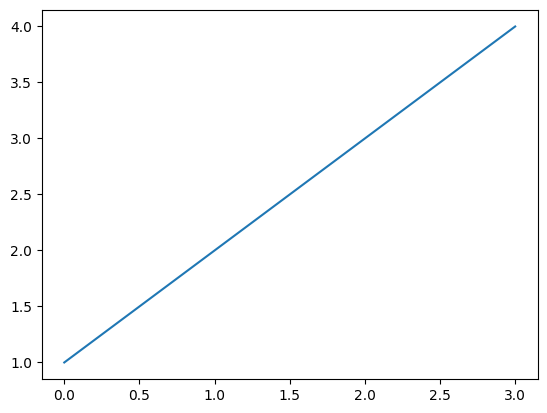

In [7]:
# 下面一行代码可以注释，默认输出，如果被'%matplotlib qt'等指令修改后，可以使用'%matplotlib inline'修改回来
%matplotlib inline   
import matplotlib.pyplot as plt
plt.plot([1,2,3,4])

- 顺便使用一个例子说明'%cofig'魔法指令的使用；

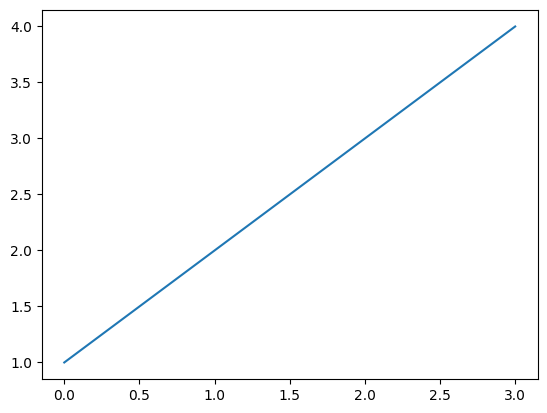

In [24]:
# 设置图形分辨率
%config InlineBackend.figure_format = 'svg'  # 矢量图
%config InlineBackend.figure_format = 'retina'  # 高分辨率

# 设置图形大小
%config InlineBackend.rc = {'figure.figsize': (10, 8)}
%config InlineBackend.rc = {'figure.dpi': 50}

%matplotlib inline   
import matplotlib.pyplot as plt
plt.plot([1,2,3,4])

### (3) 独立的GUI输出

- 独立的python程序会自动找到合适的后端GUI，如果想在jupyter notebook中使用Qt等其他后端，则可以使用如下魔法指令：
    - `%matplotlib qt`
    - 该指令一旦执行后，`%matplotlib inline`指令就失效。

In [14]:
%matplotlib qt
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.plot(x, y)
plt.title('Qt Backend')
plt.show()

- 代码说明：
    - 代码执行后，不会在页面嵌入输出图形，而是弹出一个GUI窗体。
    - 在不同的平台与环境下，其他的GUI后端可能不一定支持，QT跨平台，目前都支持。

## 2.2. 交互式输出

- 我们在上面知道，在没有调用'plt.show()'的情况下，图形也能输出。这是我们默认开启了交互式输出模式。
    - `plt.ion()`：开启交互式模式
    - `plt.ioff()`：关闭交互式模式
    - `plt.isinteractive()`：判断当前交互状态
    - `plt.pause(interval)`：在交互模式下短暂暂停，确保图形更新显示，其中时间参数单位为**秒**。

In [2]:
%matplotlib qt
import matplotlib.pyplot as plt
import numpy as np

# 启用交互式模式
plt.ion()

# 创建多个图形窗口
fig, ax = plt.subplots(figsize=(8, 4), dpi=100)

x = np.linspace(0, 4*np.pi, 200)

# 初始化图形
[line] = ax.plot(x, np.sin(x), 'r-', linewidth=2)
# line,  = ax.plot(x, np.sin(x), 'r-', linewidth=2)
ax.set_title('sin')
ax.grid(True)

# 动态更新
for idx in range(1, 200):
    y = np.sin(x[:idx])
    # print(y.shape, x[:idx].shape)
    # 更新数据
    line.set_data(x[:idx], y)
    fig.canvas.draw()
    fig.canvas.flush_events()
    
    plt.pause(0.1)

# 禁用交互模式
plt.ioff()
print("动画完成")

# 可以选择保持图形显示
# plt.show()

动画完成


- 代码说明：
    - 上面交互式输出的动画效果，需要在QT GUI后端下才能体验效果。

-------